In [2]:
import numpy as np
if not hasattr(np, 'matrix'):
    np.matrix = np.array  # patch tạm thời
    

In [4]:
import sys
sys.setrecursionlimit(10000)  # Tăng giới hạn recursion

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Style chung cho tất cả biểu đồ
plt.rcParams.update({
    'figure.dpi'      : 130,
    'font.family'     : 'DejaVu Sans',
    'axes.spines.top' : False,
    'axes.spines.right': False,
})
PALETTE = ['#2ecc71','#f39c12','#e74c3c']  # positive, neutral, negative

# Đường dẫn
ROOT_DIR      = Path().resolve().parent
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
FIGURES_DIR   = ROOT_DIR / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Chỉ load các cột cần thiết để tiết kiệm RAM
MERGED_PATH = ROOT_DIR / 'data' / 'processed' / 'merged_clean.parquet'
df = pq.read_table(
    MERGED_PATH,
    columns=['rating', 'sentiment', 'verified_purchase',
             'text_length', 'year', 'month',
             'main_category', 'price']
).to_pandas()

print(f' Loaded merged: {df.shape}')
print(f'   Columns: {df.columns.tolist()}')

 Loaded merged: (62381837, 8)
   Columns: ['rating', 'sentiment', 'verified_purchase', 'text_length', 'year', 'month', 'main_category', 'price']


phân bố rating

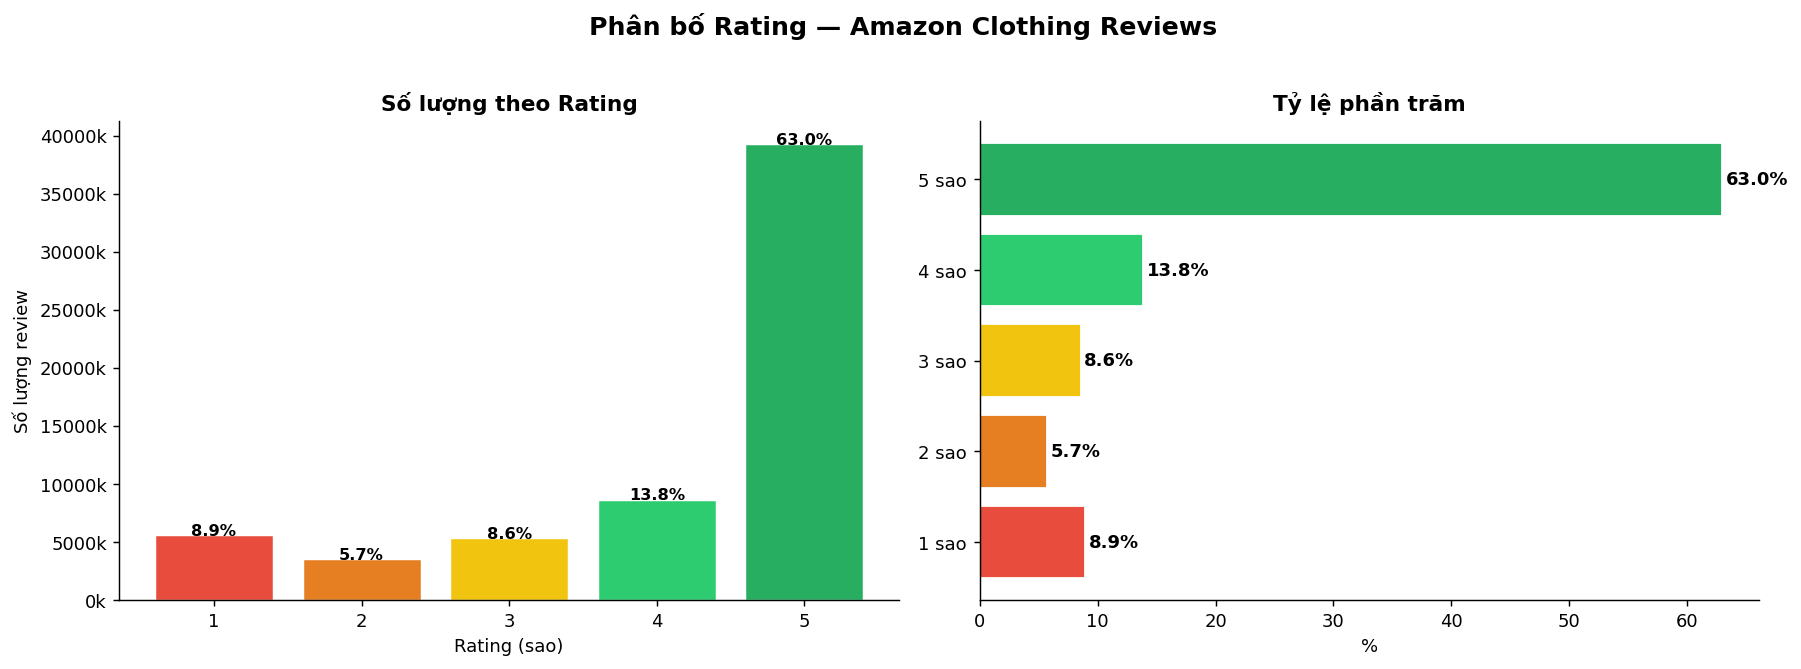

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân bố Rating — Amazon Clothing Reviews', fontsize=14, fontweight='bold', y=1.02)

#  Biểu đồ trái: Count 
rating_counts = df['rating'].value_counts().sort_index()
colors_bar    = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
bars = axes[0].bar(
    rating_counts.index.astype(int),
    rating_counts.values,
    color=colors_bar,
    edgecolor='white',
    linewidth=0.8
)
axes[0].set_title('Số lượng theo Rating', fontweight='bold')
axes[0].set_xlabel('Rating (sao)')
axes[0].set_ylabel('Số lượng review')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')
)
for bar, val in zip(bars, rating_counts.values):
    pct = val / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{pct:.1f}%',
        ha='center', fontsize=9, fontweight='bold'
    )

# Biểu đồ phải: Horizontal bar
pcts = rating_counts.values / len(df) * 100
axes[1].barh(
    [f'{int(r)} sao' for r in rating_counts.index],
    pcts,
    color=colors_bar,
    edgecolor='white'
)
axes[1].set_title('Tỷ lệ phần trăm', fontweight='bold')
axes[1].set_xlabel('%')
for i, val in enumerate(pcts):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_01_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


kiểm tra mất cân bằng dữ liệu

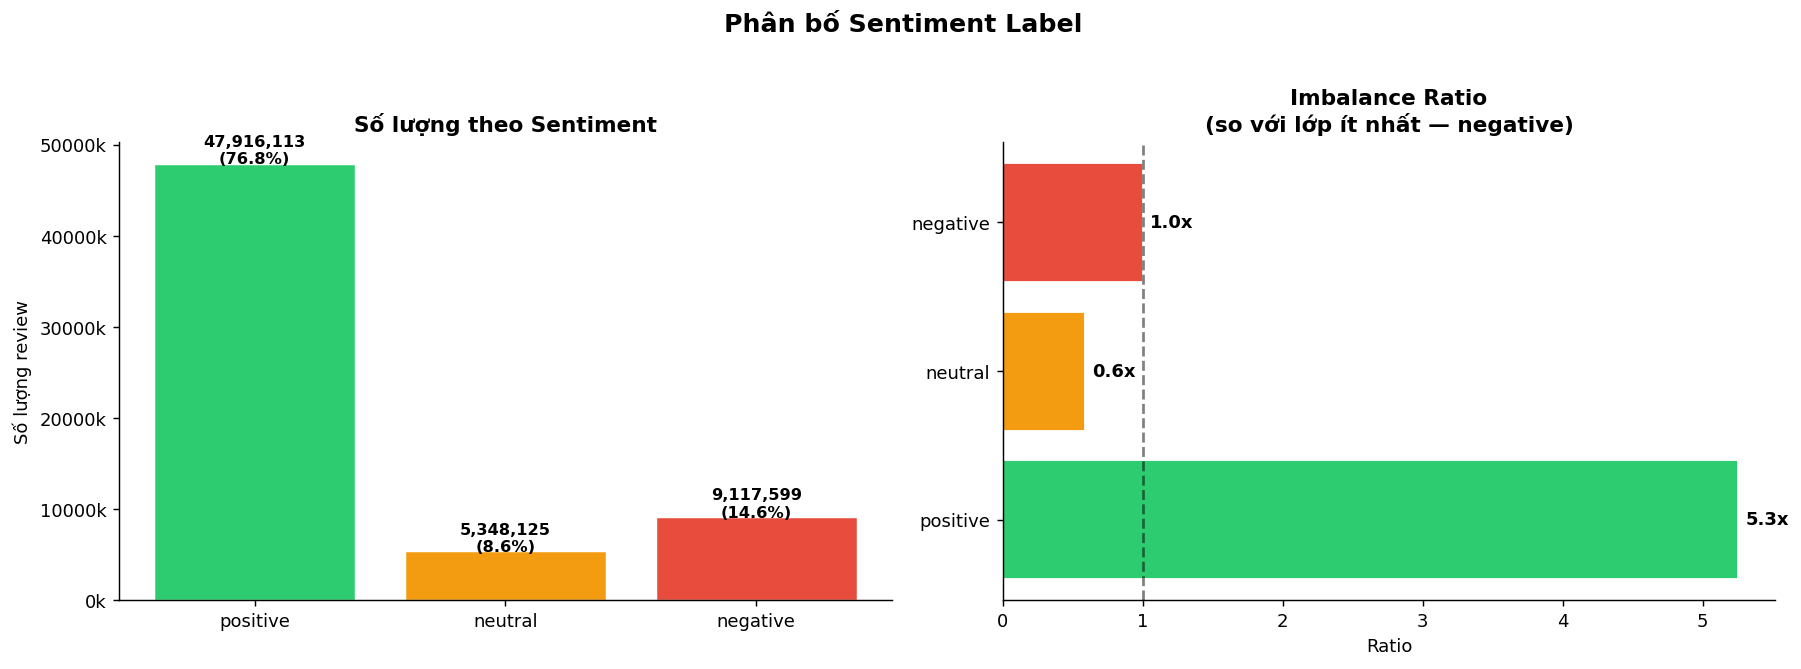


Đánh giá Imbalanced:
   positive  : 47,916,113 (76.8%)
   neutral   : 5,348,125 (8.6%)
   negative  : 9,117,599 (14.6%)


In [6]:
sentiment_order  = ['positive', 'neutral', 'negative']
sentiment_counts = df['sentiment'].value_counts().reindex(sentiment_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân bố Sentiment Label', fontsize=14, fontweight='bold', y=1.02)

# Biểu đồ trái: Bar
bars = axes[0].bar(sentiment_counts.index, sentiment_counts.values,
                    color=PALETTE, edgecolor='white', linewidth=0.8)
axes[0].set_title('Số lượng theo Sentiment', fontweight='bold')
axes[0].set_ylabel('Số lượng review')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
for bar, val in zip(bars, sentiment_counts.values):
    pct = val / len(df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                  f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')

# Biểu đồ phải: Imbalance ratio visualization
max_count = sentiment_counts.max()
ratios    = sentiment_counts / sentiment_counts['negative']  # so sánh với minority class
axes[1].barh(sentiment_counts.index, ratios.values, color=PALETTE, edgecolor='white')
axes[1].set_title('Imbalance Ratio\n(so với lớp ít nhất — negative)', fontweight='bold')
axes[1].set_xlabel('Ratio')
axes[1].axvline(1, color='black', linestyle='--', alpha=0.5)
for i, (label, ratio) in enumerate(ratios.items()):
    axes[1].text(ratio + 0.05, i, f'{ratio:.1f}x', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_02_sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Đánh giá mức độ imbalanced
pos_pct = sentiment_counts['positive'] / len(df) * 100
print('\nĐánh giá Imbalanced:')
for s, c in sentiment_counts.items():
    print(f'   {s:10}: {c:>7,} ({c/len(df)*100:.1f}%)')



In [7]:
print(df['verified_purchase'].dtype)
print(df['verified_purchase'].unique()[:10])
print(df['verified_purchase'].value_counts())

bool
[ True False]
verified_purchase
True     58647355
False     3734482
Name: count, dtype: int64


C:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Temp\ipykernel_16240\3334160942.py:29: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Temp\ipykernel_16240\3334160942.py:30: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES_DIR / 'step3_03_verified_purchase.png', dpi=150, bbox_inches='tight')
c:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


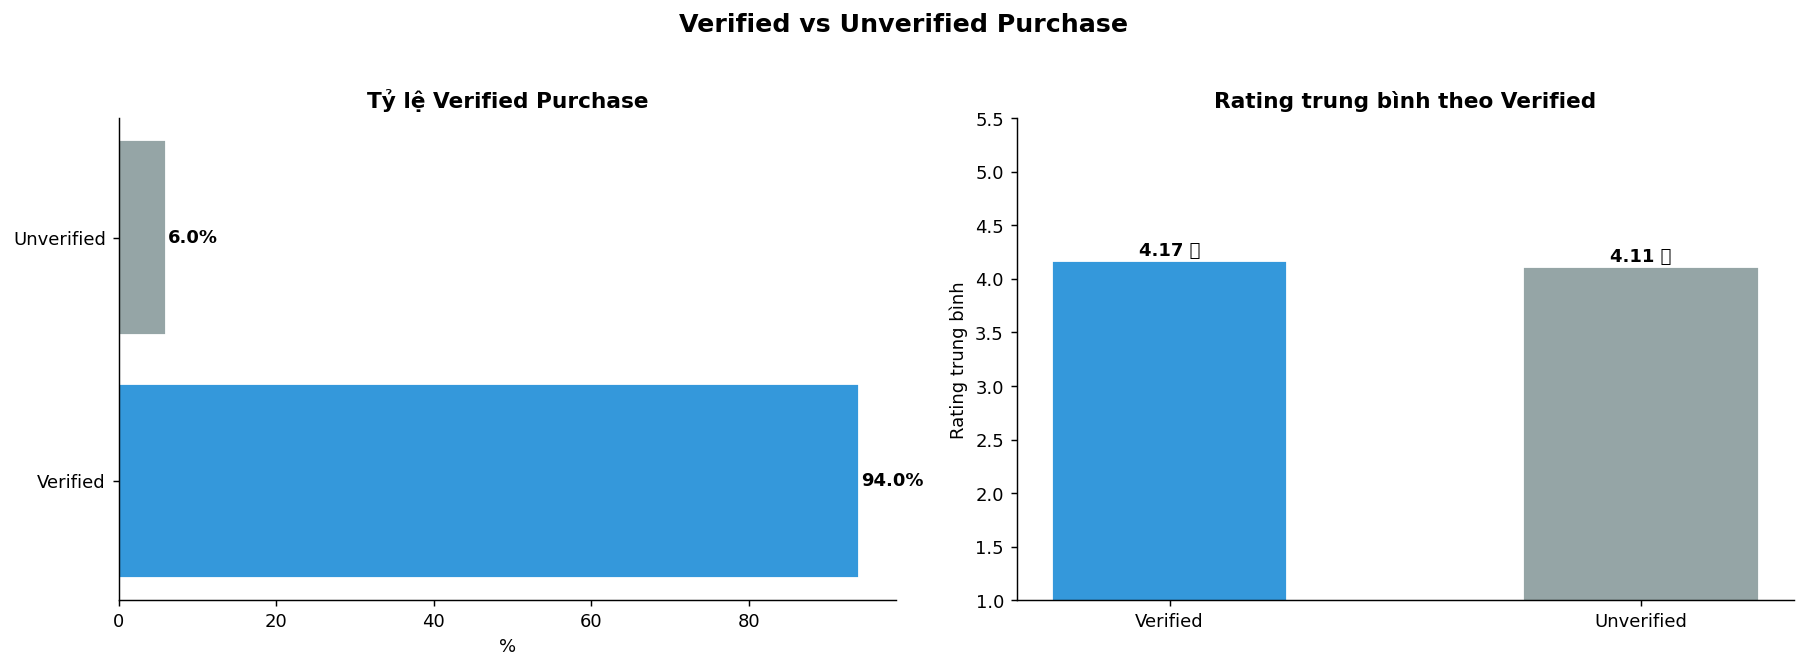


 Phân bố Verified Purchase:
   Verified    : 58,647,355 (94.0%)
   Unverified  : 3,734,482 (6.0%)

 Rating trung bình:
   Verified    : 4.165 sao
   Unverified  : 4.114 sao


In [8]:
# Map bool → label
df['vp_label'] = df['verified_purchase'].map({True: 'Verified', False: 'Unverified'})

vp_counts    = df['vp_label'].value_counts()
rating_by_vp = df.groupby('vp_label')['rating'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Verified vs Unverified Purchase', fontsize=14, fontweight='bold', y=1.02)

# Biểu đồ trái: Tỷ lệ
pcts   = vp_counts.values / len(df) * 100
labels = list(vp_counts.index)
axes[0].barh(labels, pcts, color=['#3498db', '#95a5a6'], edgecolor='white')
axes[0].set_title('Tỷ lệ Verified Purchase', fontweight='bold')
axes[0].set_xlabel('%')
for i, val in enumerate(pcts):
    axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontweight='bold')

# Biểu đồ phải: Rating trung bình
labels2 = list(rating_by_vp.index)
values2 = list(rating_by_vp.values)
axes[1].bar(labels2, values2, color=['#3498db', '#95a5a6'], edgecolor='white', width=0.5)
axes[1].set_title('Rating trung bình theo Verified', fontweight='bold')
axes[1].set_ylabel('Rating trung bình')
axes[1].set_ylim(1, 5.5)
for i, val in enumerate(values2):
    axes[1].text(i, val + 0.05, f'{val:.2f} ⭐', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_03_verified_purchase.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Phân bố Verified Purchase:')
for label, cnt in vp_counts.items():
    print(f'   {label:12}: {cnt:,} ({cnt/len(df)*100:.1f}%)')

print('\n Rating trung bình:')
for label, mean_r in rating_by_vp.items():
    print(f'   {label:12}: {mean_r:.3f} sao')

In [9]:
print(df.columns.tolist())
print(len(df))

['rating', 'sentiment', 'verified_purchase', 'text_length', 'year', 'month', 'main_category', 'price', 'vp_label']
62381837


In [10]:
import pyarrow.parquet as pq
ROOT_DIR = ROOT_DIR  
meta = pq.read_table(
    ROOT_DIR / 'data' / 'processed' / 'meta_clean.parquet',
    columns=['parent_asin', 'main_category', 'categories']
).to_pandas()
print(meta['categories'])
print(f"\nmain_category unique: {meta['main_category'].nunique()}")

0          [Clothing, Shoes & Jewelry, Women, Clothing, S...
1          [Clothing, Shoes & Jewelry, Women, Shoes, Outd...
2          [Clothing, Shoes & Jewelry, Women, Shoes, Sand...
3          [Clothing, Shoes & Jewelry, Novelty & More, Cl...
4          [Clothing, Shoes & Jewelry, Women, Handbags & ...
                                 ...                        
7218476    [Clothing, Shoes & Jewelry, Women, Clothing, D...
7218477    [Clothing, Shoes & Jewelry, Women, Clothing, S...
7218478    [Clothing, Shoes & Jewelry, Men, Shoes, Fashio...
7218479    [Clothing, Shoes & Jewelry, Women, Clothing, S...
7218480    [Clothing, Shoes & Jewelry, Women, Handbags & ...
Name: categories, Length: 7218481, dtype: object

main_category unique: 2


In [11]:
import numpy as np

def extract_sub_cat(cats):
    if isinstance(cats, (list, np.ndarray)) and len(cats) > 1:
        return str(cats[1])  # lấy index 1 = level 2
    return 'Unknown'

meta['sub_category'] = meta['categories'].apply(extract_sub_cat)

print("Sub-categories top 15:")
print(meta['sub_category'].value_counts().head(15))
print(f"\nTổng unique: {meta['sub_category'].nunique()}")

Sub-categories top 15:
sub_category
Women                                3781083
Men                                  1443845
Novelty & More                        499836
Girls                                 260670
Boot Shop                             169848
Westlake                              166014
Sport Specific Clothing               164127
Boys                                  151552
Baby                                  148730
Luggage & Travel Gear                 142304
Costumes & Accessories                126577
Shoe, Jewelry & Watch Accessories      58610
Toddler Test                            7077
Top 50 by Product Type                  5412
Plus-Size Fashion                       5200
Name: count, dtype: int64

Tổng unique: 2906


In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import pyarrow.parquet as pq

plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

ROOT_DIR      = Path().resolve().parent
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
FIGURES_DIR   = ROOT_DIR / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pq.read_table(
    PROCESSED_DIR / 'merged_clean.parquet',
    columns=['rating', 'sentiment', 'year', 'month']
).to_pandas()

# Lọc năm hợp lệ (2000-2024)
df = df[df['year'].between(2000, 2024)]
df['year']  = df['year'].astype(int)
df['month'] = df['month'].astype(int)

print(f'Loaded: {len(df):,} rows')
print(f'   Năm: {df["year"].min()} → {df["year"].max()}')

Loaded: 62,381,812 rows
   Năm: 2000 → 2023


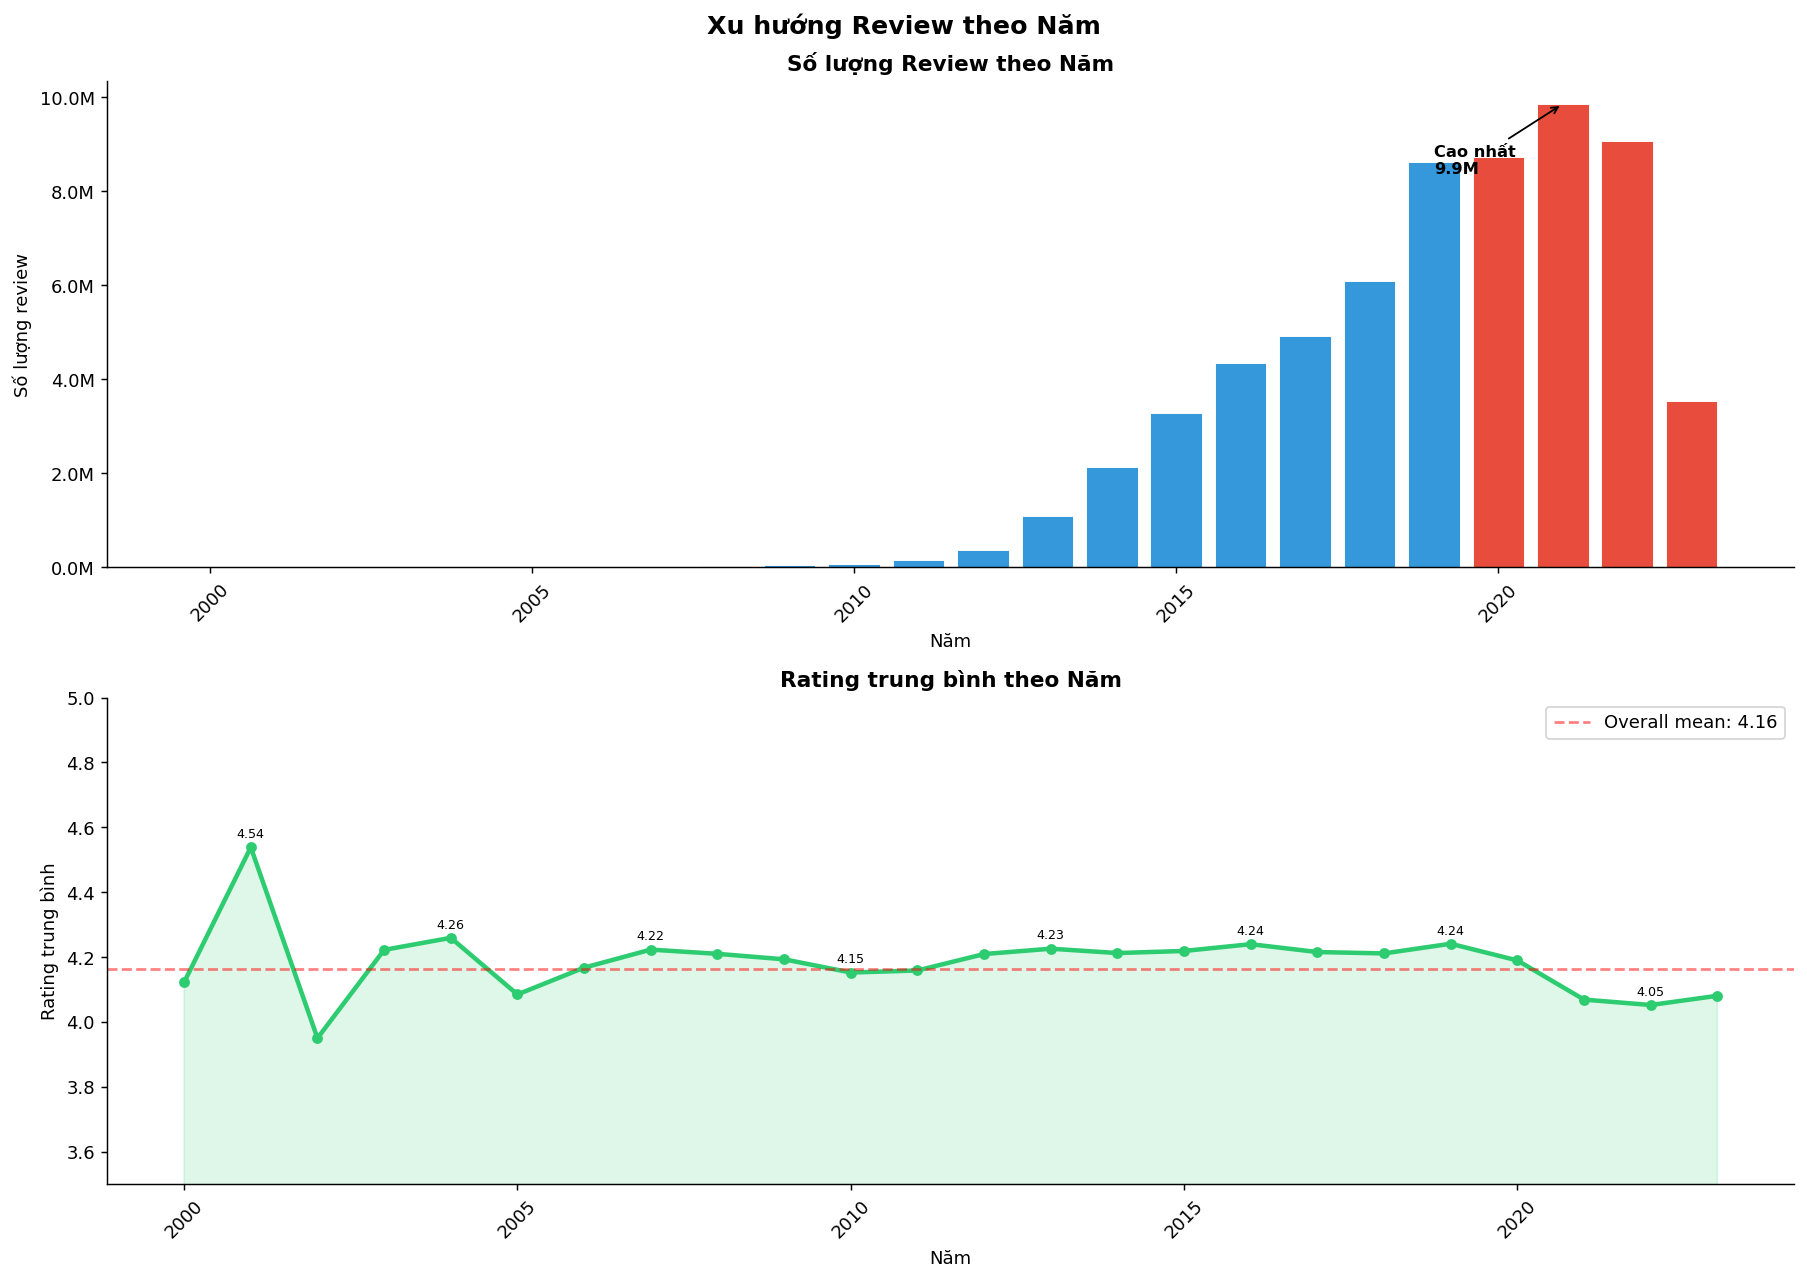


 Top 5 năm nhiều review nhất:
 year  review_count  mean_rating
 2021       9855211     4.068926
 2022       9060149     4.052236
 2020       8722153     4.189653
 2019       8630921     4.241127
 2018       6088802     4.211331


In [13]:
#  Xu hướng review theo năm
#  Amazon Clothing ngày càng phổ biến hơn không?

yearly = df.groupby('year').agg(
    review_count  = ('rating', 'count'),
    mean_rating   = ('rating', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Xu hướng Review theo Năm', fontsize=14, fontweight='bold')

# Biểu đồ 1: Số lượng review theo năm 
colors = ['#3498db' if y < 2020 else '#e74c3c' for y in yearly['year']]
bars = axes[0].bar(yearly['year'], yearly['review_count'],
                    color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Số lượng Review theo Năm', fontweight='bold')
axes[0].set_ylabel('Số lượng review')
axes[0].set_xlabel('Năm')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
)
# Đánh dấu năm có nhiều review nhất
max_year = yearly.loc[yearly['review_count'].idxmax()]
axes[0].annotate(
    f'Cao nhất\n{max_year["review_count"]/1e6:.1f}M',
    xy=(max_year['year'], max_year['review_count']),
    xytext=(max_year['year'] - 2, max_year['review_count'] * 0.85),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9, fontweight='bold'
)
axes[0].tick_params(axis='x', rotation=45)

# Biểu đồ 2: Rating trung bình theo năm 
axes[1].plot(yearly['year'], yearly['mean_rating'],
              color='#2ecc71', linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(yearly['year'], yearly['mean_rating'],
                      alpha=0.15, color='#2ecc71')
axes[1].set_title('Rating trung bình theo Năm', fontweight='bold')
axes[1].set_ylabel('Rating trung bình')
axes[1].set_xlabel('Năm')
axes[1].set_ylim(3.5, 5.0)
axes[1].axhline(df['rating'].mean(), color='red', linestyle='--',
                 alpha=0.5, label=f'Overall mean: {df["rating"].mean():.2f}')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
for _, row in yearly.iterrows():
    if row['year'] % 3 == 0:  # hiện label mỗi 3 năm
        axes[1].text(row['year'], row['mean_rating'] + 0.03,
                      f'{row["mean_rating"]:.2f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_05_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Top 5 năm nhiều review nhất:')
print(yearly.nlargest(5, 'review_count')[['year','review_count','mean_rating']].to_string(index=False))

C:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Temp\ipykernel_16240\2723337844.py:49: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Temp\ipykernel_16240\2723337844.py:50: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES_DIR / 'step3_06_monthly_seasonality.png', dpi=150, bbox_inches='tight')
c:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


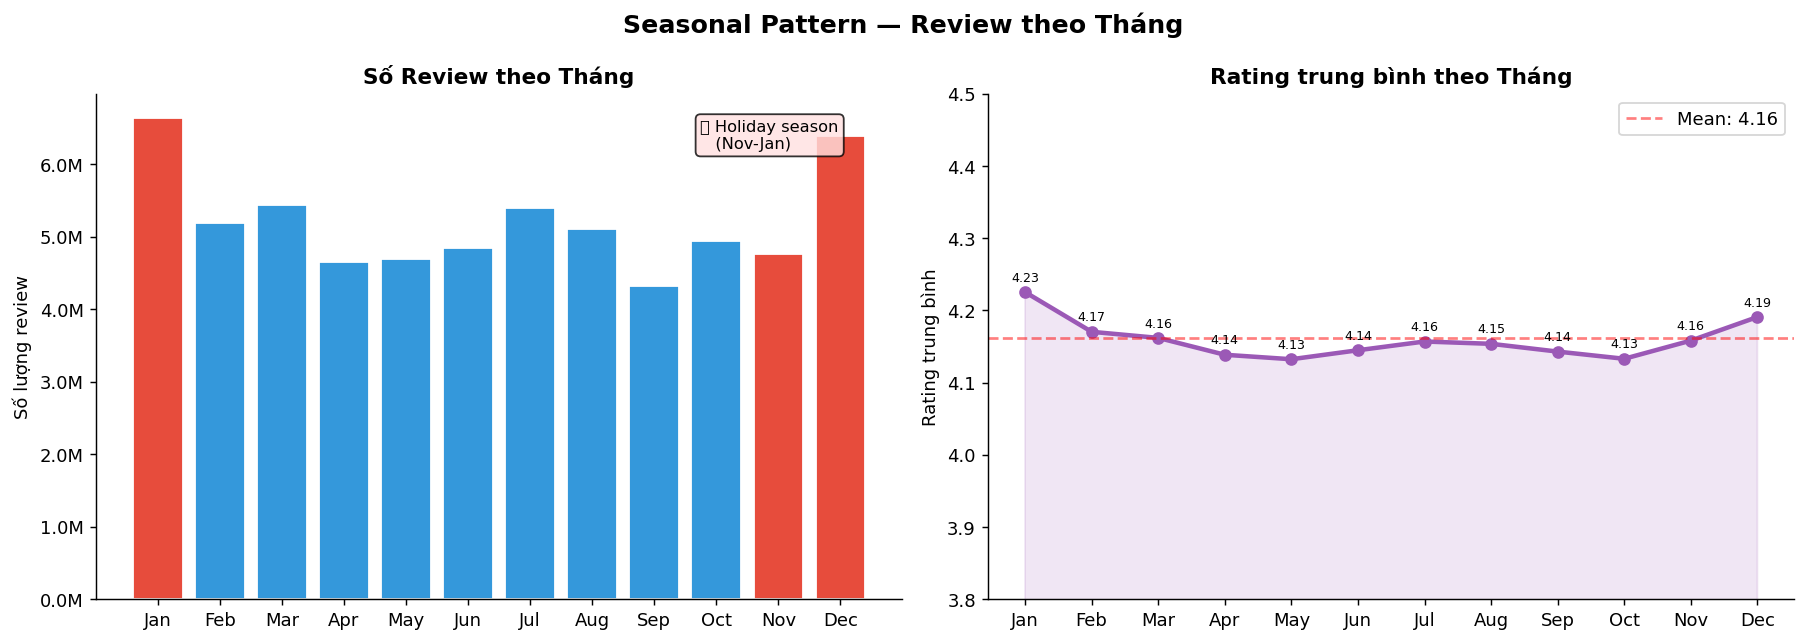


 Review theo tháng:
   Jan: ██████████████████████████████ 6.64M
   Feb: ███████████████████████ 5.20M
   Mar: ████████████████████████ 5.44M
   Apr: █████████████████████ 4.65M
   May: █████████████████████ 4.69M
   Jun: █████████████████████ 4.85M
   Jul: ████████████████████████ 5.40M
   Aug: ███████████████████████ 5.10M
   Sep: ███████████████████ 4.32M
   Oct: ██████████████████████ 4.94M
   Nov: █████████████████████ 4.76M
   Dec: ████████████████████████████ 6.40M


In [14]:
# Seasonal pattern theo tháng
# Tháng nào mua sắm nhiều nhất?

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = df.groupby('month').agg(
    review_count = ('rating', 'count'),
    mean_rating  = ('rating', 'mean')
).reset_index()
monthly['month_name'] = monthly['month'].apply(lambda x: MONTH_NAMES[x-1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Seasonal Pattern — Review theo Tháng', fontsize=14, fontweight='bold')

# Biểu đồ trái: Số review theo tháng
colors_m = ['#e74c3c' if m in [11, 12, 1] else '#3498db'
             for m in monthly['month']]
bars = axes[0].bar(monthly['month_name'], monthly['review_count'],
                    color=colors_m, edgecolor='white')
axes[0].set_title('Số Review theo Tháng', fontweight='bold')
axes[0].set_ylabel('Số lượng review')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')
)
# Chú thích mùa holiday
axes[0].text(0.75, 0.95, '🔴 Holiday season\n   (Nov-Jan)',
              transform=axes[0].transAxes, fontsize=9,
              verticalalignment='top',
              bbox=dict(boxstyle='round', facecolor='#ffe0e0', alpha=0.8))

# Biểu đồ phải: Rating theo tháng
axes[1].plot(monthly['month_name'], monthly['mean_rating'],
              color='#9b59b6', linewidth=2.5, marker='o', markersize=6)
axes[1].fill_between(range(len(monthly)), monthly['mean_rating'],
                      alpha=0.15, color='#9b59b6')
axes[1].set_title('Rating trung bình theo Tháng', fontweight='bold')
axes[1].set_ylabel('Rating trung bình')
axes[1].set_ylim(3.8, 4.5)
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['month_name'])
axes[1].axhline(df['rating'].mean(), color='red', linestyle='--',
                 alpha=0.5, label=f'Mean: {df["rating"].mean():.2f}')
axes[1].legend()
for i, row in monthly.iterrows():
    axes[1].text(i, row['mean_rating'] + 0.015,
                  f'{row["mean_rating"]:.2f}', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_06_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n Review theo tháng:')
for _, row in monthly.iterrows():
    bar_v = '█' * int(row['review_count'] / monthly['review_count'].max() * 30)
    print(f'   {row["month_name"]:3}: {bar_v} {row["review_count"]/1e6:.2f}M')

C:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Temp\ipykernel_16240\2775893136.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sentiment_yearly = df_valid.groupby(['year', 'sentiment']).size().unstack(fill_value=0)


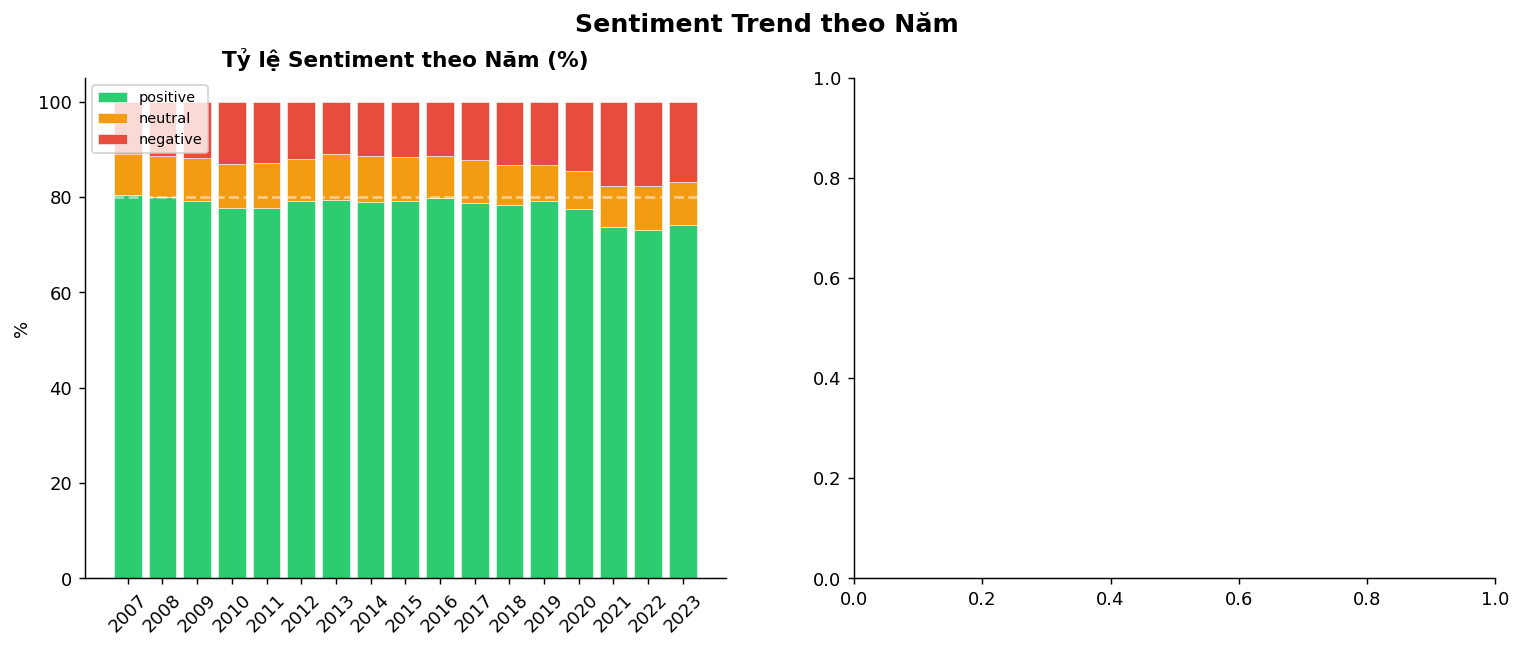

In [15]:
# Sentiment trend theo năm
# Người dùng có ngày càng hài lòng hơn không
year_counts   = df['year'].value_counts()
valid_years   = year_counts[year_counts >= 10_000].index
df_valid      = df[df['year'].isin(valid_years)]

sentiment_yearly = df_valid.groupby(['year', 'sentiment']).size().unstack(fill_value=0)
sentiment_pct    = sentiment_yearly.div(sentiment_yearly.sum(axis=1), axis=0) * 100

# Đảm bảo đủ 3 cột
for col in ['positive', 'neutral', 'negative']:
    if col not in sentiment_pct.columns:
        sentiment_pct[col] = 0
sentiment_pct = sentiment_pct[['positive', 'neutral', 'negative']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Trend theo Năm', fontsize=14, fontweight='bold')

# ---- Biểu đồ trái: Stacked bar ----
years  = sentiment_pct.index.tolist()
x_pos  = range(len(years))
colors_s = ['#2ecc71', '#f39c12', '#e74c3c']

bottom = [0] * len(years)
for col, color in zip(['positive', 'neutral', 'negative'], colors_s):
    vals = sentiment_pct[col].tolist()
    axes[0].bar(x_pos, vals, bottom=bottom, color=color,
                 label=col, edgecolor='white', linewidth=0.3)
    bottom = [b + v for b, v in zip(bottom, vals)]

axes[0].set_title('Tỷ lệ Sentiment theo Năm (%)', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].set_xticks(list(x_pos))
axes[0].set_xticklabels([str(y) for y in years], rotation=45)
axes[0].legend(loc='upper left', fontsize=8)
axes[0].axhline(80, color='white', linestyle='--', alpha=0.5)


 BƯỚC 3: EDA Chuyên Sâu
Phần 3 — Phân tích Văn bản

- Phân bố độ dài review
- Top từ phổ biến theo từng nhóm sentiment
- Word Cloud cho positive / negative
- Insight về ngôn ngữ → chuẩn bị cho Bước 4 (NLP)

In [16]:
import subprocess
subprocess.run(['pip', 'install', 'wordcloud', 'nltk', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from collections import Counter
import pyarrow.parquet as pq
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# Download stopwords
nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('english'))
# Thêm stopwords không có ý nghĩa phân tích
STOPWORDS.update(['i', 'the', 'and', 'it', 'is', 'this',
                   'to', 'a', 'in', 'of', 'for', 'my', 'so',
                   'but', 'they', 'are', 'was', 'with', 'have',
                   'one', 'get', 'not', 'also', 'very', 'much',
                   'just', 'like', 'me', 'on', 'at', 'its', 'had',
                   'be', 'as', 'an', 'we', 'he', 'she', 'that',
                   'them', 'their', 'would', 'has', 'been', 'more',
                   'will', 'no', 'if', 'what', 'up', 'out', 'do',
                   'did', 'from', 'all', 'your', 'when', 'can',
                   'about', 'there', 'were', 'or', 'even', 'some'])

plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

ROOT_DIR      = Path().resolve().parent
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
SAMPLE_DIR    = ROOT_DIR / 'data' / 'sample'
FIGURES_DIR   = ROOT_DIR / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
df = pd.read_parquet(SAMPLE_DIR / 'review_sample_100k.parquet')

print(f' Loaded: {df.shape}')
print(f'   Columns: {df.columns.tolist()}')
print(f'\n   Sentiment counts:')
print(df['sentiment'].value_counts())

 Loaded: (100000, 12)
   Columns: ['rating', 'text', 'title', 'user_id', 'parent_asin', 'timestamp', 'helpful_vote', 'verified_purchase', 'year', 'month', 'sentiment', 'text_length']

   Sentiment counts:
sentiment
positive    82131
negative     9220
neutral      8649
Name: count, dtype: int64


In [18]:
# Làm sạch text và đếm từ phổ biến
def clean_text(text):
    """Làm sạch text: lowercase, bỏ ký tự đặc biệt, bỏ stopwords"""
    text  = str(text).lower()
    text  = re.sub(r'[^a-z\s]', ' ', text)  # chỉ giữ chữ cái
    words = text.split()
    words = [w for w in words if w not in STOPWORDS and len(w) > 2]
    return words

# Tách text theo sentiment
word_counts = {}
for sentiment in ['positive', 'neutral', 'negative']:
    subset = df[df['sentiment'] == sentiment].head(20_000)
    all_words = []
    for text in subset['text'].astype(str):
        all_words.extend(clean_text(text))
    word_counts[sentiment] = Counter(all_words)
    print(f'   {sentiment:10}: {len(all_words):,} words tổng | {len(word_counts[sentiment]):,} unique')

   positive  : 517,614 words tổng | 16,742 unique
   neutral   : 243,400 words tổng | 11,953 unique
   negative  : 190,731 words tổng | 11,251 unique


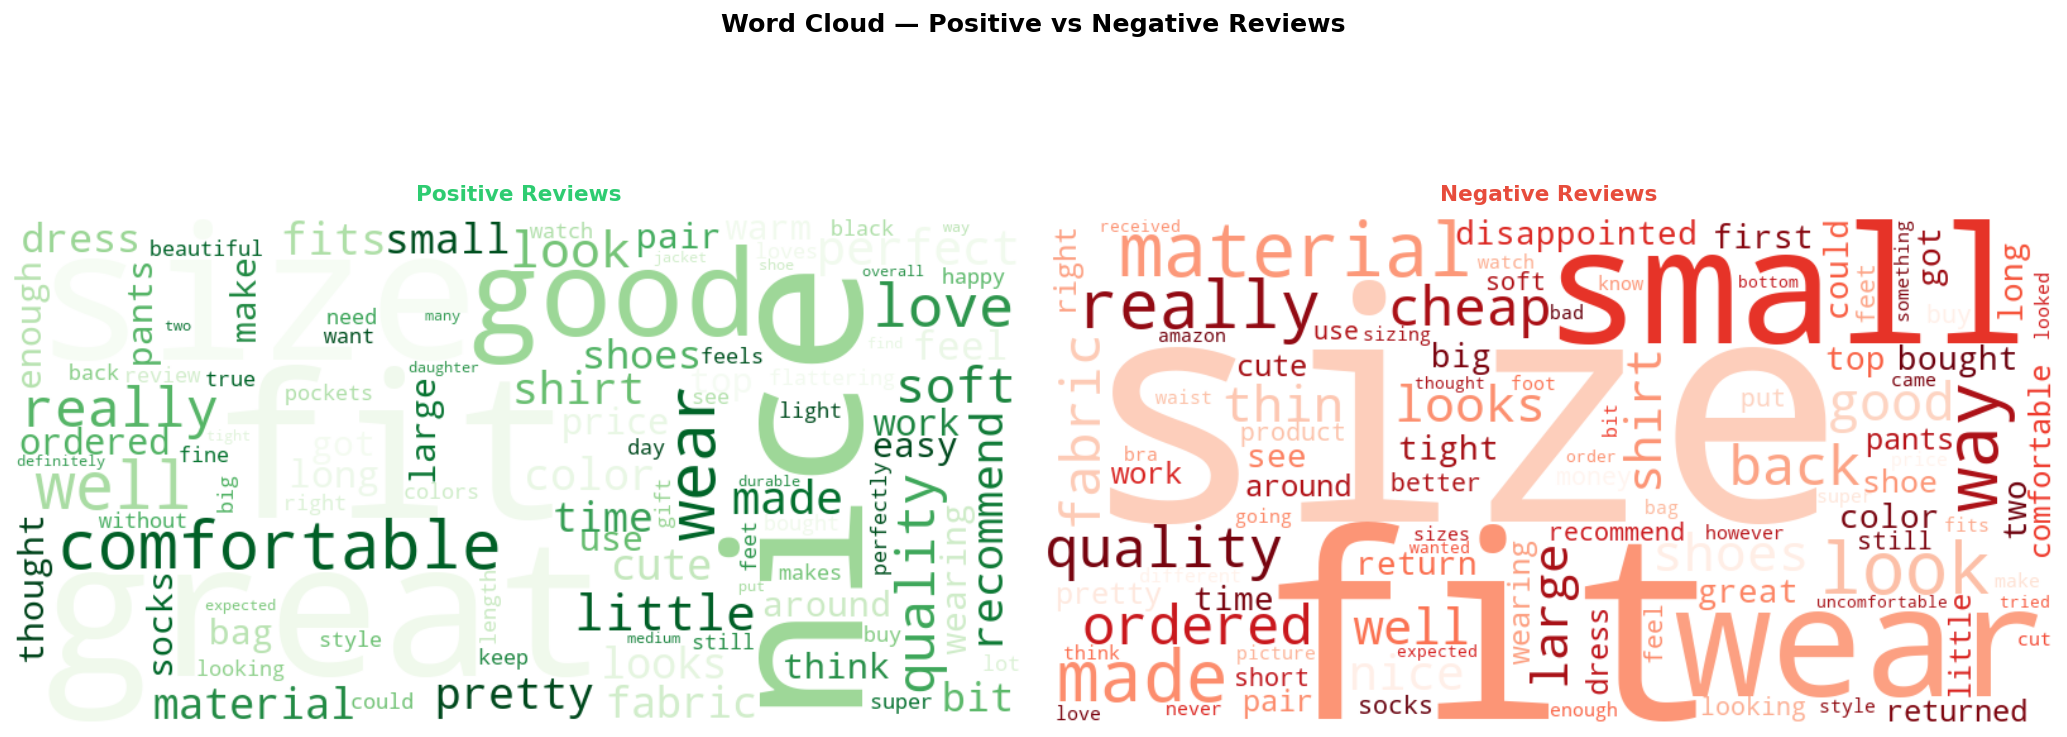

In [23]:
#  Word Cloud cho positive và negative

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Word Cloud — Positive vs Negative Reviews', fontsize=14, fontweight='bold')

wc_configs = [
    ('positive', '#2ecc71', 'Positive Reviews'),
    ('negative', '#e74c3c', 'Negative Reviews'),
]

for ax, (sentiment, color, title) in zip(axes, wc_configs):
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap='Greens' if sentiment == 'positive' else 'Reds',
        max_words=100,
        stopwords=STOPWORDS,
        collocations=False
    ).generate_from_frequencies(word_counts[sentiment])

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontweight='bold', fontsize=12,
                  color=color, pad=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_10_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Temp\ipykernel_16240\2232271202.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Temp\ipykernel_16240\2232271202.py:47: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Temp\ipykernel_16240\2232271202.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES_DIR / 'step3_11_distinctive_words.png', dpi=150, bbox_inches='tight')
C:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Temp\ipykernel_16240\2232271202.py:48: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(FIGURES_DIR / 'step3_11_distinctive_words.png', dpi=150, bbox_inches='tight')
c:\Users\admin.DESKTOP-2BT6N2R\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools

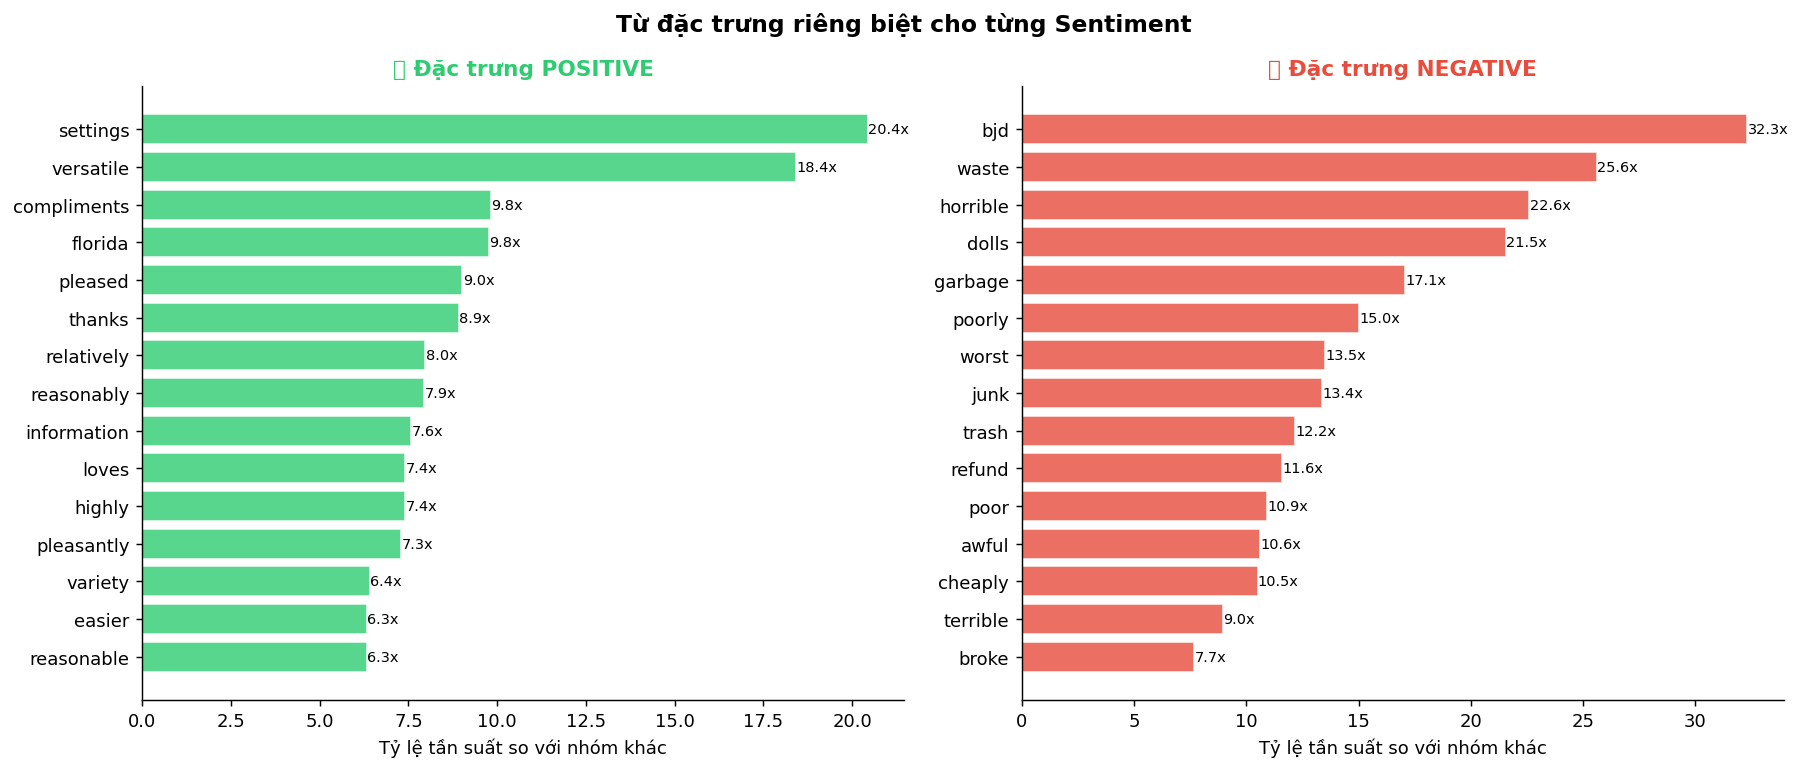

In [24]:
# Từ riêng cho từng nhóm sentiment
# Loại bỏ từ chung xuất hiện ở cả positive lẫn negative
# Chỉ giữ từ đặc trưng riêng → có giá trị NLP cao hơn

def get_distinctive_words(target, others, top_n=15):
    """Lấy từ đặc trưng của nhóm target so với các nhóm khác"""
    target_total = sum(target.values())
    other_total  = sum(others.values())

    distinctive = {}
    for word, count in target.items():
        # Từ phải xuất hiện đủ nhiều ở cả 2 nhóm
        if count < 50:              # ← tăng từ 10 lên 50
            continue
        if others.get(word, 0) < 10:  # ← bỏ từ không có ở nhóm khác
            continue

        target_freq = count / target_total
        other_freq  = others.get(word, 0) / other_total
        distinctive[word] = target_freq / other_freq

    return sorted(distinctive.items(), key=lambda x: -x[1])[:top_n]

# Từ đặc trưng positive (không xuất hiện nhiều ở negative)
from collections import Counter
combined_neg_neu = word_counts['negative'] + word_counts['neutral']
combined_pos_neu = word_counts['positive'] + word_counts['neutral']

pos_distinctive = get_distinctive_words(word_counts['positive'], combined_neg_neu)
neg_distinctive = get_distinctive_words(word_counts['negative'], combined_pos_neu)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Từ đặc trưng riêng biệt cho từng Sentiment', fontsize=13, fontweight='bold')

for ax, (distinctive, color, title) in zip(axes, [
    (pos_distinctive, '#2ecc71', '✅ Đặc trưng POSITIVE'),
    (neg_distinctive, '#e74c3c', '❌ Đặc trưng NEGATIVE'),
]):
    words  = [w for w, _ in distinctive]
    ratios = [r for _, r in distinctive]
    ax.barh(words[::-1], ratios[::-1], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontweight='bold', color=color)
    ax.set_xlabel('Tỷ lệ tần suất so với nhóm khác')
    for i, (w, r) in enumerate(zip(words[::-1], ratios[::-1])):
        ax.text(r + 0.01, i, f'{r:.1f}x', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_11_distinctive_words.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
import pyarrow.parquet as pq

plt.rcParams.update({
    'figure.dpi'       : 130,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

ROOT_DIR      = Path().resolve().parent
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
FIGURES_DIR   = ROOT_DIR / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pq.read_table(
    PROCESSED_DIR / 'review_clean.parquet',
    columns=['user_id', 'parent_asin', 'rating', 'sentiment']
).to_pandas()

# Load meta để lấy price
df_meta = pq.read_table(
    PROCESSED_DIR / 'meta_clean.parquet',
    columns=['parent_asin', 'price']
).to_pandas()

print(f' Review loaded: {len(df):,} rows')
print(f' Meta loaded  : {len(df_meta):,} rows')

📊 Thống kê số reviews mỗi user:
count    21942115.0
mean            2.8
std             5.2
min             1.0
25%             1.0
50%             2.0
75%             3.0
max          4239.0
Name: n_reviews, dtype: float64


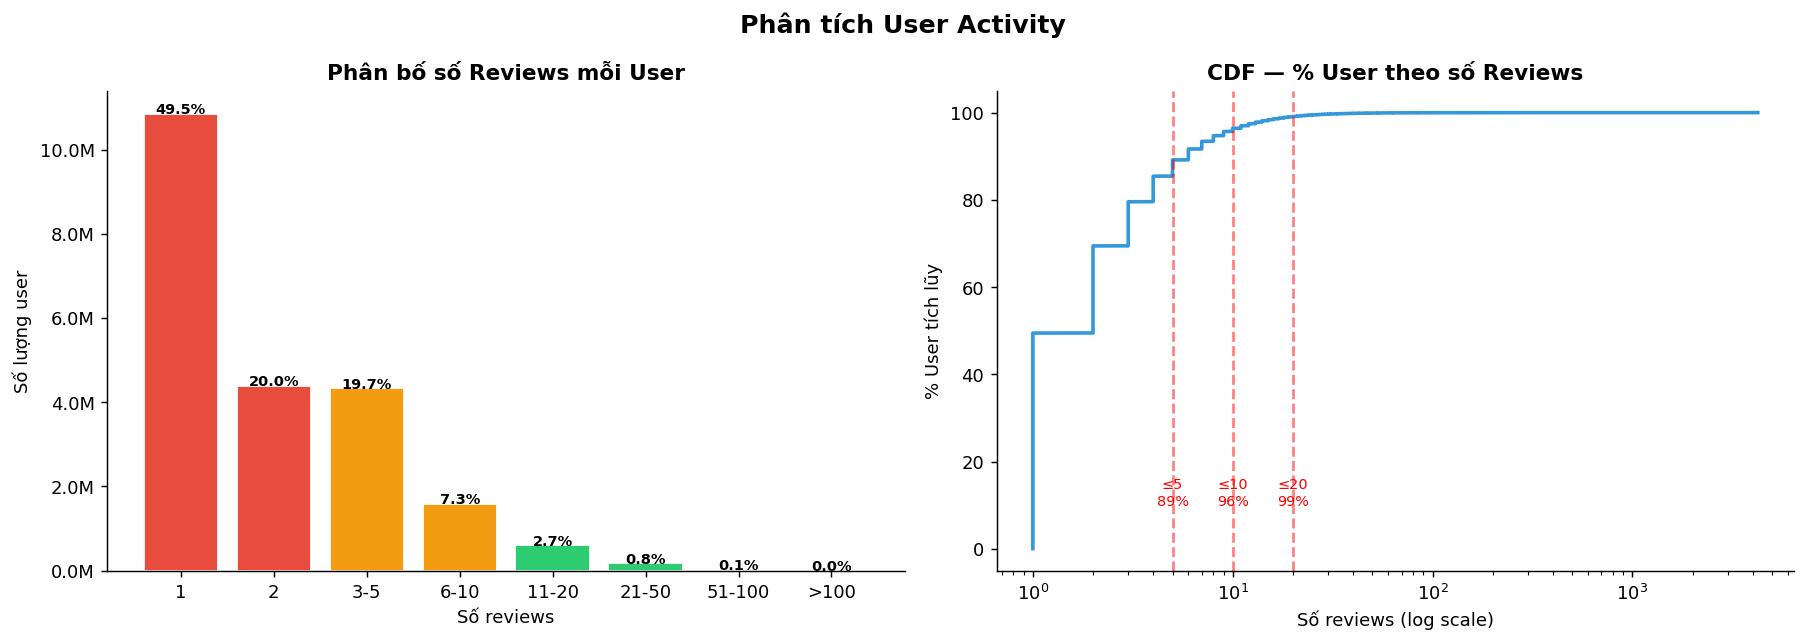


📊 Phân nhóm user:
        1 reviews: 10,851,356 users (49.5%)
        2 reviews: 4,383,429 users (20.0%)
      3-5 reviews: 4,327,968 users (19.7%)
     6-10 reviews: 1,591,991 users (7.3%)
    11-20 reviews:  595,898 users (2.7%)
    21-50 reviews:  170,819 users (0.8%)
   51-100 reviews:   16,497 users (0.1%)
     >100 reviews:    4,157 users (0.0%)


In [ ]:
# Phân bố số reviews mỗi user
# Phần lớn user review bao nhiêu sản phẩm

user_counts = df.groupby('user_id').size().reset_index(name='n_reviews')

print('Thống kê số reviews mỗi user:')
print(user_counts['n_reviews'].describe().round(1))

# Phân nhóm user
bins   = [0, 1, 2, 5, 10, 20, 50, 100, float('inf')]
labels = ['1', '2', '3-5', '6-10', '11-20', '21-50', '51-100', '>100']
user_counts['group'] = pd.cut(user_counts['n_reviews'],
                               bins=bins, labels=labels)
group_counts = user_counts['group'].value_counts().reindex(labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân tích User Activity', fontsize=14, fontweight='bold')

# ---- Biểu đồ trái: Phân nhóm user ----
pcts  = group_counts.values / len(user_counts) * 100
colors = ['#e74c3c' if i < 2 else '#f39c12' if i < 4 else '#2ecc71'
           for i in range(len(labels))]
bars = axes[0].bar(labels, group_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Phân bố số Reviews mỗi User', fontweight='bold')
axes[0].set_xlabel('Số reviews')
axes[0].set_ylabel('Số lượng user')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
for bar, pct, val in zip(bars, pcts, group_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 1000,
                  f'{pct:.1f}%', ha='center', fontsize=8, fontweight='bold')

# ---- Biểu đồ phải: CDF (Cumulative Distribution) ----
sorted_counts = np.sort(user_counts['n_reviews'].values)
cdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts) * 100
axes[1].plot(sorted_counts, cdf, color='#3498db', linewidth=2)
axes[1].set_xscale('log')
axes[1].set_title('CDF — % User theo số Reviews', fontweight='bold')
axes[1].set_xlabel('Số reviews (log scale)')
axes[1].set_ylabel('% User tích lũy')
# Đánh dấu mốc quan trọng
for threshold in [5, 10, 20]:
    pct_below = (user_counts['n_reviews'] <= threshold).mean() * 100
    axes[1].axvline(threshold, color='red', linestyle='--', alpha=0.5)
    axes[1].text(threshold, 10, f'≤{threshold}\n{pct_below:.0f}%',
                  ha='center', fontsize=8, color='red')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_12_user_activity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Phân nhóm user:')
for label, cnt, pct in zip(labels, group_counts.values, pcts):
    print(f'   {label:>6} reviews: {cnt:>8,} users ({pct:.1f}%)')

In [6]:
# Lấy tên sản phẩm từ meta
top10_asins = item_counts.nlargest(10, 'n_reviews')['parent_asin'].tolist()

df_meta_title = pq.read_table(
    PROCESSED_DIR / 'meta_clean.parquet',
    columns=['parent_asin', 'title', 'price']
).to_pandas()

top10_info = item_counts.nlargest(10, 'n_reviews').merge(
    df_meta_title, on='parent_asin', how='left'
)

print('📊 Top 10 sản phẩm được review nhiều nhất:')
print('-' * 80)
for _, row in top10_info.iterrows():
    title = str(row['title'])[:60] + '...' if len(str(row['title'])) > 60 else str(row['title'])
    print(f"  {row['n_reviews']:>7,} reviews | ⭐{row['mean_rating']:.2f} | ${row['price'] if pd.notna(row['price']) else 'N/A'}")
    print(f"  → {title}")
    print()

📊 Top 10 sản phẩm được review nhiều nhất:
--------------------------------------------------------------------------------
  264,308 reviews | ⭐4.32 | $17.989999771118164
  → Funny Civil Engineers TShirt I'm A Crazy Civil Engineering T...

   38,520 reviews | ⭐4.32 | $29.969999313354492
  → Hail Satan Unicorn Cat Rainbow, Funny Death Metal Meme Pullo...

   32,270 reviews | ⭐4.54 | $N/A
  → Crocs Unisex-Adult Classic Clog

   23,904 reviews | ⭐3.94 | $23.950000762939453
  → Andy Griffith Show | Floyd's Barber Shop Classic TV Premium ...

   23,646 reviews | ⭐4.13 | $18.989999771118164
  → SATINA High Waisted Leggings for Women - Capri & Full Length...

   19,328 reviews | ⭐4.37 | $20.700000762939453
  → Dickies Men's Dri-tech Moisture Control Crew Socks Multipack

   17,769 reviews | ⭐4.04 | $46.220001220703125
  → Levi's Men's 505 Regular Fit Jeans (Also Available in Big & ...

   17,588 reviews | ⭐3.91 | $34.9900016784668
  → Women's Walking Shoes Sock Sneakers - Mesh Slip On Air Cus

📊 MA TRẬN USER-ITEM
   Số users           :   21,942,115
   Số items           :    7,039,165
   Số ratings thực tế :   62,381,837
   Số ô có thể có     : 154,454,167,933,975
   Sparsity           :    100.0000%
   Density            :    0.000040%


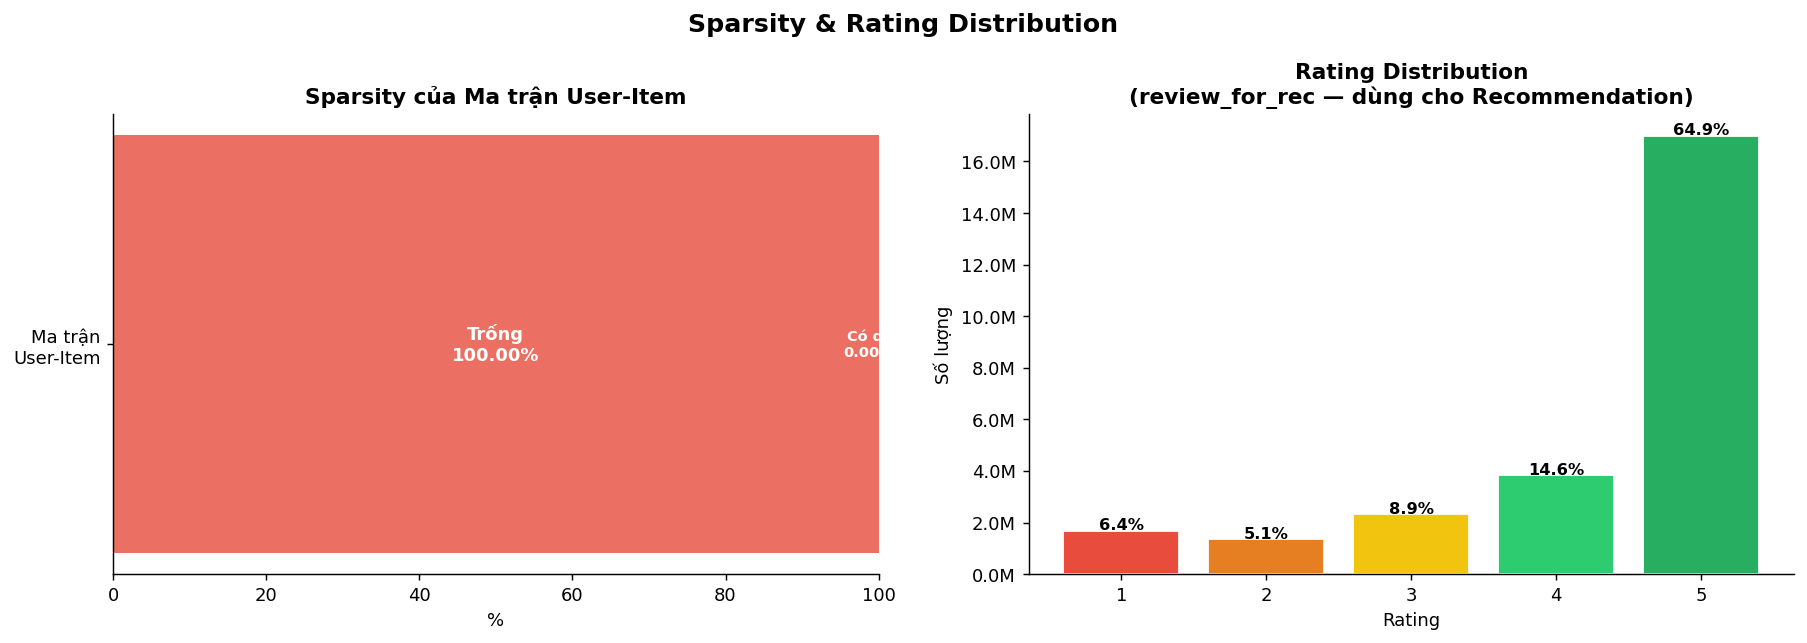


⚠️  Nhận xét Sparsity:
   Ma trận CỰC KỲ THƯA (100.0000%)
   → SVD/ALS xử lý tốt sparse matrix
   → NCF cần embedding layer đủ lớn
   → Content-Based không bị ảnh hưởng bởi sparsity


In [ ]:
# Tính độ thưa (Sparsity) của ma trận User-Item
# Sparsity = % ô trống trong ma trận user × item
# Sparsity cao → Collaborative Filtering khó học hơn
n_users    = df['user_id'].nunique()
n_items    = df['parent_asin'].nunique()
n_ratings  = len(df)
n_possible = n_users * n_items
sparsity   = (1 - n_ratings / n_possible) * 100

print('=' * 55)
print('📊 MA TRẬN USER-ITEM')
print('=' * 55)
print(f'   Số users           : {n_users:>12,}')
print(f'   Số items           : {n_items:>12,}')
print(f'   Số ratings thực tế : {n_ratings:>12,}')
print(f'   Số ô có thể có     : {n_possible:>12,}')
print(f'   Sparsity           : {sparsity:>11.4f}%')
print(f'   Density            : {100-sparsity:>11.6f}%')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sparsity & Rating Distribution', fontsize=14, fontweight='bold')

# ---- Biểu đồ trái: Sparsity gauge ----
axes[0].barh(['Ma trận\nUser-Item'], [sparsity],
              color='#e74c3c', alpha=0.8, height=0.4)
axes[0].barh(['Ma trận\nUser-Item'], [100 - sparsity],
              left=[sparsity], color='#2ecc71', alpha=0.8, height=0.4)
axes[0].set_xlim(0, 100)
axes[0].set_title('Sparsity của Ma trận User-Item', fontweight='bold')
axes[0].set_xlabel('%')
axes[0].text(sparsity/2, 0, f'Trống\n{sparsity:.2f}%',
              ha='center', va='center', color='white', fontweight='bold')
axes[0].text(sparsity + (100-sparsity)/2, 0,
              f'Có data\n{100-sparsity:.4f}%',
              ha='center', va='center', color='white', fontweight='bold', fontsize=8)

# ---- Biểu đồ phải: Rating distribution trong review_for_rec ----
rec_df = pq.read_table(
    PROCESSED_DIR / 'review_for_rec.parquet',
    columns=['rating']
).to_pandas()

rc = rec_df['rating'].value_counts().sort_index()
axes[1].bar(rc.index.astype(int), rc.values,
             color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60'],
             edgecolor='white')
axes[1].set_title('Rating Distribution\n(review_for_rec — dùng cho Recommendation)', fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Số lượng')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')
)
for i, (rating, count) in enumerate(rc.items()):
    axes[1].text(rating, count + 50000,
                  f'{count/len(rec_df)*100:.1f}%',
                  ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_14_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n⚠️  Nhận xét Sparsity:')
if sparsity > 99.9:
    print(f'   Ma trận CỰC KỲ THƯA ({sparsity:.4f}%)')
    print(f'   → SVD/ALS xử lý tốt sparse matrix')
    print(f'   → NCF cần embedding layer đủ lớn')
    print(f'   → Content-Based không bị ảnh hưởng bởi sparsity')

Số reviews có thông tin giá: 41,908,814


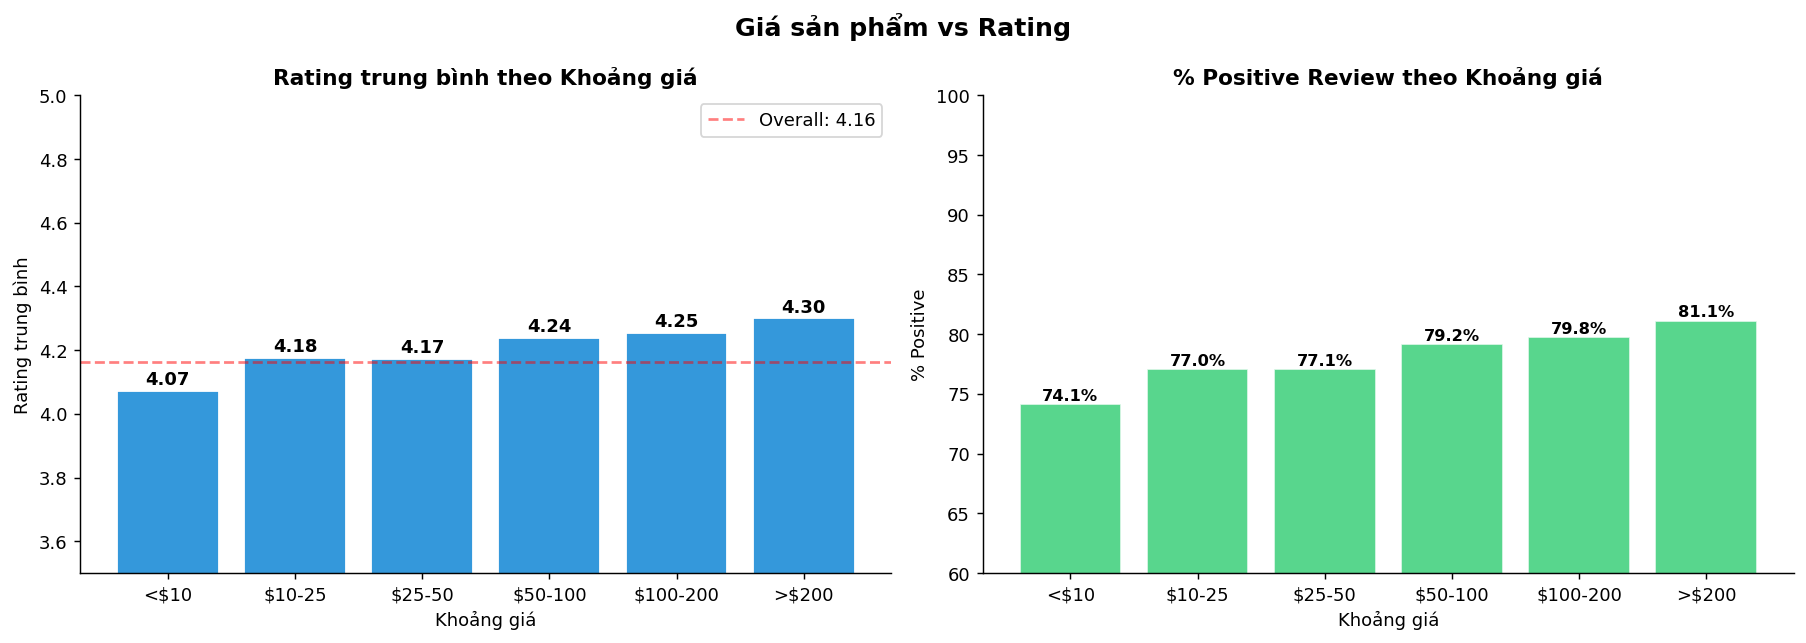


📊 Rating theo khoảng giá:
price_group  mean_rating  review_count  pct_positive
       <$10     4.072019       3087160     74.146627
     $10-25     4.176243      18552245     77.049150
     $25-50     4.173525      14506796     77.081025
    $50-100     4.237852       4089149     79.211053
   $100-200     4.252829       1411666     79.767381
      >$200     4.299628        261798     81.139275


In [ ]:
# Mối quan hệ giữa Giá và Rating

# Merge review với meta để lấy price
df_price = df.merge(df_meta, on='parent_asin', how='left')
df_price = df_price[
    df_price['price'].notna() &
    df_price['price'].between(1, 500)  # lọc giá hợp lý
]

print(f'Số reviews có thông tin giá: {len(df_price):,}')

# Chia giá thành các khoảng
price_bins   = [0, 10, 25, 50, 100, 200, 500]
price_labels = ['<$10', '$10-25', '$25-50', '$50-100', '$100-200', '>$200']
df_price['price_group'] = pd.cut(df_price['price'],
                                   bins=price_bins, labels=price_labels)

price_stats = df_price.groupby('price_group', observed=True).agg(
    mean_rating  = ('rating', 'mean'),
    review_count = ('rating', 'count'),
    pct_positive = ('sentiment', lambda x: (x == 'positive').mean() * 100)
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Giá sản phẩm vs Rating', fontsize=14, fontweight='bold')

# ---- Biểu đồ trái: Rating theo khoảng giá ----
colors_p = ['#3498db'] * len(price_stats)
bars = axes[0].bar(price_stats['price_group'].astype(str),
                    price_stats['mean_rating'],
                    color=colors_p, edgecolor='white')
axes[0].set_title('Rating trung bình theo Khoảng giá', fontweight='bold')
axes[0].set_ylabel('Rating trung bình')
axes[0].set_xlabel('Khoảng giá')
axes[0].set_ylim(3.5, 5.0)
axes[0].axhline(df['rating'].mean(), color='red', linestyle='--',
                 alpha=0.5, label=f'Overall: {df["rating"].mean():.2f}')
axes[0].legend()
for bar, val in zip(bars, price_stats['mean_rating']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.02,
                  f'{val:.2f}', ha='center', fontweight='bold')

# ---- Biểu đồ phải: % Positive theo khoảng giá ----
axes[1].bar(price_stats['price_group'].astype(str),
             price_stats['pct_positive'],
             color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title('% Positive Review theo Khoảng giá', fontweight='bold')
axes[1].set_ylabel('% Positive')
axes[1].set_xlabel('Khoảng giá')
axes[1].set_ylim(60, 100)
for i, val in enumerate(price_stats['pct_positive']):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step3_15_price_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Rating theo khoảng giá:')
print(price_stats[['price_group','mean_rating','review_count','pct_positive']].to_string(index=False))